# Proyecto UD3
#### UD3. Aprendizaxe Non Supervisada
#### MP. Sistemas de Aprendizaxe Automáticos
#### IES de Teis (Vigo), Vanesa Resúa Eiras, Cristina Gómez Alonso
### Dataset: Países

Nuestro gallego de oro, Amancio Ortega, ha cumplido 89 años y le da vueltas a cuál será su legado en este mundo.
Es por ello, que ha contactado con el IES de Teis para que le ayudemos a identicar aquellos países más necesitados teniendo en cuenta factores socio-económicos y de salud para determinar el estado de cada país.
Una vez categorizados, la Fundación Ortega podrá abrir hospitales, escuelas y comedores sociales en dichos países.

Disponemos de un dataset con la información mundial de 166 países.

Lista de atributos para cada país:

* país: nombre del país
* mort_inf: número de niños menores de 5 años muertos por cada 1000 nacimientos
* exportaciones: exportaciones de bienes y servicios per cápita. Expresado como % del PIB per cápita
* salud: gasto total en salud per cápita. Expresado como % del PIB per cápita
* importaciones: importaciones de bienes y servicios per cápita. Expresado como % del PIB per cápita
* ingresos: ingresos netos por persona
* inflacion: la medida de la tasa de crecimiento anual del PIB total
* esp_vida: La cantidad promedio de años que viviría un niño recién nacido si los patrones de mortalidad actuales se mantuvieran iguales
* num_hijos: el número de hijos que nacerían de cada mujer si las tasas actuales de fecundidad por edad se mantuvieran iguales.
* pib: el PIB per cápita. Calculado como el PIB total dividido por la población total.

A Amancio no le interesan mucho los números ni las gráficas, sino que le extraigas conclusiones de cada uno de los pasos qué realizas y porqué los realizas.

## 1. Importación del dataset

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import pandas as pd


In [7]:
import pandas as pd
df_paises = pd.read_csv('doc/paises.csv')
df_paises

,pais,mort_inf,exportaciones,salud,importaciones,ingresos,inflacion,esp_vida,num_hijos,pib
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [8]:
df_paises.describe()

,mort_inf,exportaciones,salud,importaciones,ingresos,inflacion,esp_vida,num_hijos,pib
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [9]:
df_paises.isnull().sum()

pais             0
mort_inf         0
exportaciones    0
salud            0
importaciones    0
ingresos         0
inflacion        0
esp_vida         0
num_hijos        0
pib              0
dtype: int64

No hay nulos

## 2. EDA&Preprocessing (2 puntos)

In [10]:
print(f"Nuestro dataframe tiene {df_paises.shape[0]} filas y {df_paises.shape[1]} columnas")

Nuestro dataframe tiene 167 filas y 10 columnas


In [11]:
df_paises.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pais           167 non-null    object 
 1   mort_inf       167 non-null    float64
 2   exportaciones  167 non-null    float64
 3   salud          167 non-null    float64
 4   importaciones  167 non-null    float64
 5   ingresos       167 non-null    int64  
 6   inflacion      167 non-null    float64
 7   esp_vida       167 non-null    float64
 8   num_hijos      167 non-null    float64
 9   pib            167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


<div style="
    background: linear-gradient(135deg, #4a90e2, #50c0f0);
    padding: 25px;
    border-radius: 12px;
    box-shadow: 0 8px 20px rgba(0, 0, 0, 0.15);
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    max-width: 700px;
">
<p style="
        color: #ffffff;
        font-size: 18px;
        line-height: 1.6;
        margin: 0;
        text-align: justify;
    ">
Vemos los tipos de datos de la columnas, para ver si hay datos categóricos
    </p>

</div>

In [12]:
df_paises.duplicated().sum()

np.int64(0)

<div style="
    background: linear-gradient(135deg, #4a90e2, #50c0f0);
    padding: 25px;
    border-radius: 12px;
    box-shadow: 0 8px 20px rgba(0, 0, 0, 0.15);
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    max-width: 700px;
">
<p style="
        color: #ffffff;
        font-size: 18px;
        line-height: 1.6;
        margin: 0;
        text-align: justify;
    ">
        Comprobamos que no haya duplicados 
    </p>

</div>

<h2 style="
    background: linear-gradient(90deg, #4a90e2, #50c0f0);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    font-size: 28px;
    font-weight: 700;
    margin: 20px 0;
    border-bottom: 2px solid #50c0f0;
    display: inline-block;
    padding-bottom: 5px;
">
    2.1 Gráficos
</h2>

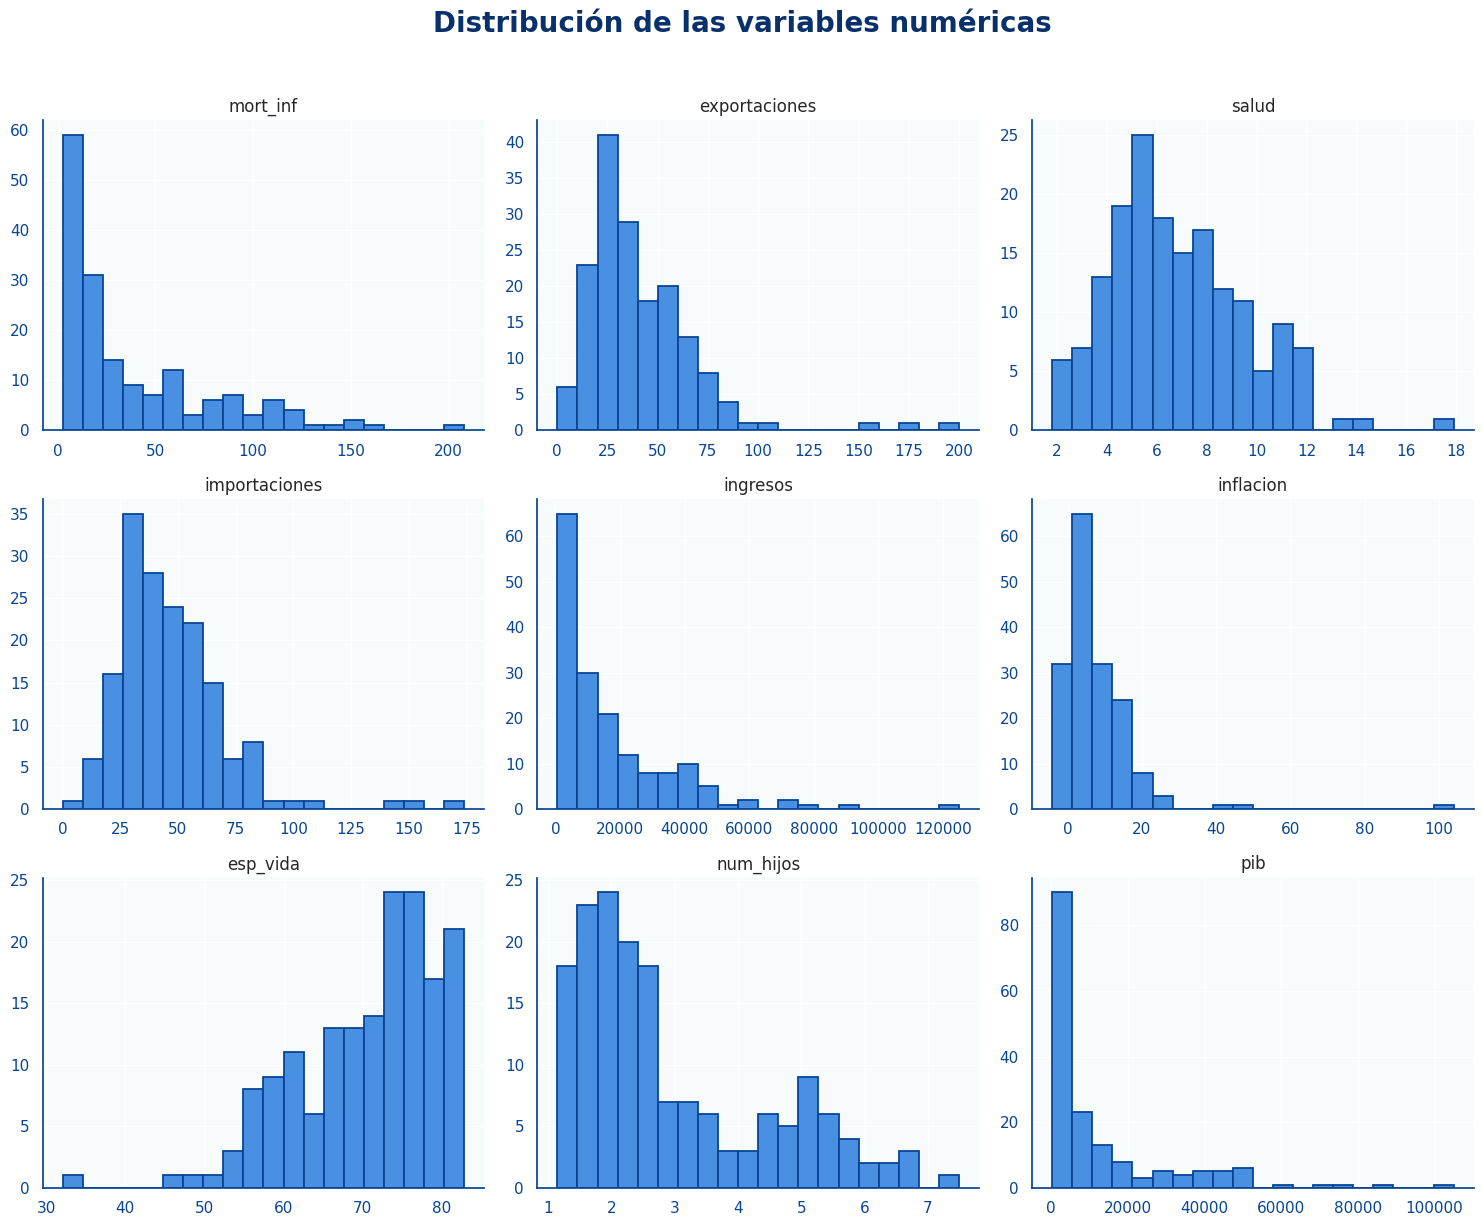

In [23]:
sns.set_theme(style="whitegrid")

color_barras = "#4a90e2"
color_borde = "#084594"

axes = df_paises.drop('pais', axis=1).hist(
    figsize=(15, 12),
    bins=20,
    color=color_barras,
    edgecolor=color_borde,
    linewidth=1.3
)

plt.suptitle(
    'Distribución de las variables numéricas', 
    fontsize=20, 
    fontweight='bold', 
    color='#08306b', 
    y=1.02
)

for ax_row in axes:
    for ax in ax_row:
        ax.set_facecolor('#f7fbfc')  # Fondo suave
        ax.grid(True, color='white', linewidth=1.0)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('#084594')
        ax.spines['bottom'].set_color('#084594')
        ax.tick_params(axis='x', colors='#084594')
        ax.tick_params(axis='y', colors='#084594')

plt.tight_layout()
plt.show()

<div style="
    background: #f0f8ff;
    padding: 25px 36px;
    border-radius: 15px;
    box-shadow: 0 10px 25px rgba(43, 55, 214, 0.1);
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    color: #08306b;
    max-width: 900px;
    line-height: 1.7;
    border-left: 6px solid #4a90e2;
">

<h3 style="
        font-size: 22px;
        font-weight: bold;
        margin-bottom: 20px;
        margin-left: 20px
        color: #084594;
        text-align: center;
        text-transform: uppercase;
    ">
        Conclusión
    </h3>

<div style="
        background: #d9ebf9;
        border-radius: 10px;
        padding: 15px 20px;
        margin-bottom: 15px;
        border-left: 4px solid #4a90e2;
    ">
        Las variables económicas como el PIB, ingresos o exportaciones no siguen una distribución normal. Tienen una fuerte asimetría positiva dando a demostrar  la desigualdad real del mundo: la mayoría de países se agrupa en niveles de riqueza bajos o medios, mientras que un grupo muy reducido presenta valores extremos.
    </div>

 <div style="
        background: #e1f0fc;
        border-radius: 10px;
        padding: 15px 20px;
        margin-bottom: 15px;
        border-left: 4px solid #3a78c2;
    ">
        <strong>Diferencia de magnitudes:</strong> <br>
        Variables como PIB o ingresos se mueven en decenas de miles, mientras que <em>num_hijos</em> se mueve en unidades, de 1 a 8.
    </div>

 <div style="
        background: #d0e6fb;
        border-radius: 10px;
        padding: 15px 20px;
        margin-bottom: 0;
        border-left: 4px solid #2f63a5;
    ">
        Esta asimetría y gran diferencia de escalas justifican y hacen necesario el uso de <strong>StandardScaler</strong>. Si no estandarizamos, el modelo de clustering (K-Means) dará un peso enorme al PIB por sus números grandes, ignorando variables pequeñas pero importantes como la tasa de natalidad o la mortalidad infantil.
    </div>

</div>

In [13]:
# Realiza un análisis exploratorio de los datos. ¿Puedes extraer alguna información?
# Realiza un preprocesado de los datos antes de pasar el siguiente apartado

## 3. Creación de los modelos, entrenamiento, predicciones y representación gráfica (4 puntos)

In [14]:
# Crea al menos un modelo no supervisado, entrénalo y visualiza los resultados. ¿Cuál es el número óptimo de clústers? ¿Por qué? Qué conclusiones extraemos?

## 4. PCA (2 puntos)

In [15]:
# ¿Tiene sentido la reducción de dimensionalidad de este dataset? Demúestralo y justifica tus respuestas.


## 5. Conclusiones (2 puntos)

In [16]:
# ¿Qué información le podemos hacer llegar a Amancio?